In [1]:
import numpy as np
import pandas as pd
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.fft import fft, ifft, dct, idct, dst, idst

from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import StatePreparation, HGate, SwapGate, MCXGate, SdgGate
from qiskit.quantum_info import Statevector, DensityMatrix, state_fidelity

from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error
from qiskit_ibm_runtime.fake_provider import FakeSherbrooke

## Configs

In [2]:
WINDOW_SIZE = 256

RETENTION_RATIOS = [1.00, 0.85, 0.75, 0.50, 0.45, 0.25, 0.10, 0.05, 0.02, 0.01]

SEED = 42

CW_DATASET = Path("cw_dataset")
CLEAN_DIR = CW_DATASET / "clean"
NOISY_DIR = CW_DATASET / "noisy"
ENVELOPE_DIR = CW_DATASET / "envelopes"
AUDIO_DIR = CW_DATASET / "audio"
AUDIO_CLEAN_DIR = AUDIO_DIR / "clean"
AUDIO_NOISY_DIR = AUDIO_DIR / "noisy"
METADATA_FILE = CW_DATASET / "metadata.csv"

### Noise Model

In [3]:
FAKE_DEVICES = {
    "ideal": None,
    "sherbrooke": FakeSherbrooke(),
}

NOISE_SIMULATORS = {
    name: AerSimulator(method="density_matrix") if backend is None
    else AerSimulator.from_backend(backend, method="density_matrix")
    for name, backend in FAKE_DEVICES.items()
}

## Helper functions

In [4]:
def validate_window(x):
    x = np.asarray(x)
    if x.ndim != 1:
        raise ValueError("Input must be 1-D")

    n = len(x)
    if n == 0 or (n & (n - 1)) != 0:
        raise ValueError(f"Length must be a power of two, got {n}")

    return x

def prepare_amplitudes(x):
    x = validate_window(x)
    x = np.asarray(x, dtype=np.complex128)
    x[np.abs(x) < 1e-14] = 0.0
    norm = np.linalg.norm(x)
    if norm <= 1e-15: 
        return None, 0.0
    amplitudes = x / norm

    qc = QuantumCircuit(int(np.log2(len(x))))
    qc.append(StatePreparation(amplitudes, normalize=True), range(qc.num_qubits))
    return qc, norm

def run_transform(x, transform_circuit):
    prep, input_norm = prepare_amplitudes(x)
    if prep is None:
        return (np.zeros_like(x, dtype=np.complex128,), None,)

    if prep.num_qubits != transform_circuit.num_qubits:
        raise ValueError("State preparation and transform have different qubit counts.")

    prep.compose(transform_circuit, inplace=True,)
    state = Statevector.from_instruction(prep).data
    result = (np.asarray(state) * input_norm)
    return result, prep

def append_zero_controlled_h(qc, controls, target):
    if not controls:
        qc.h(target)
        return

    for q in controls:
        qc.x(q)

    gate = HGate().control(len(controls))
    qc.append(gate, [*controls, target])
    for q in controls:
        qc.x(q)

def append_zero_controlled_swap(qc, controls, q1, q2):
    if not controls:
        qc.swap(q1, q2)
        return

    for q in controls:
        qc.x(q)

    gate = SwapGate().control(len(controls))
    qc.append(gate, [*controls, q1, q2])
    for q in controls:
        qc.x(q)

def append_mcx(qc, controls, target):
    controls = list(controls)
    if len(controls) == 0:
        qc.x(target)
    elif len(controls) == 1:
        qc.cx(controls[0], target)
    else:
        qc.append(MCXGate(len(controls)), [*controls, target])

def append_ctrl_ones_complement(qc, data, ctrl):
    for q in data:
        qc.cx(ctrl, q)

def append_ctrl_increment(qc, data, ctrl):
    n = len(data)
    for i in range(n - 1, 0, -1):
        controls = [ctrl, *data[:i]]
        append_mcx(qc, controls, data[i])
    qc.cx(ctrl, data[0],)

def append_ctrl_decrement(qc, data, ctrl):
    n = len(data)
    qc.cx(ctrl, data[0],)
    for i in range(1, n):
        controls = [ctrl, *data[:i],]
        append_mcx(qc, controls, data[i])

def append_ctrl_twos_complement(qc, data, ctrl):
    append_ctrl_ones_complement(qc, data, ctrl)
    append_ctrl_increment(qc, data, ctrl)

def append_vn(qc, data, ctrl):
    # H ⊗ I
    qc.h(ctrl)
    # pi_1:
    # |1,x> -> |1, one's_complement(x)>
    append_ctrl_ones_complement(qc, data, ctrl)

def append_d1(qc, data, ctrl):
    n = len(data)
    N = 2 ** n
    theta = np.pi / (2 * N)
    # delta_2:
    # active when ctrl = 1
    # K_i = X L_i^dag X
    for i, q in enumerate(data):
        angle = (2 ** i) * theta
        qc.x(q)
        qc.cp(-angle, ctrl, q)
        qc.x(q)

    # delta_1:
    # active when ctrl = 0
    qc.x(ctrl)
    for i, q in enumerate(data):
        angle = (2 ** i) * theta
        qc.cp(angle, ctrl, q)

    qc.x(ctrl)
    # C = diag(1, conjugate(omega))
    qc.p(-theta, ctrl,)

def append_g(qc, data, ctrl):
    # Base B^T = S H
    qc.h(ctrl)
    qc.s(ctrl)
    # Convert condition:
    # data == 000...0
    # into
    # data == 111...1
    for q in data:
        qc.x(q)

    controls = list(data)
    # Controlled J = Sdg H Sdg
    qc.append(SdgGate().control(len(controls)), [*controls, ctrl])
    qc.append(HGate().control(len(controls)), [*controls, ctrl])
    qc.append(SdgGate().control(len(controls)), [*controls, ctrl])
    # Restore data
    for q in data:
        qc.x(q)

def append_un_dagger(qc, data, ctrl):
    # D1
    append_d1(qc, data, ctrl)
    # Conditional two's complement
    append_ctrl_twos_complement(qc, data, ctrl)
    # Conditional branch mixing
    append_g(qc, data, ctrl,)
    # Conditional decrement
    append_ctrl_decrement(qc, data, ctrl)

def run_branch_transform(x, transform):
    x = validate_window(x)
    x = np.asarray(x, dtype=np.complex128)
    x[np.abs(x) < 1e-14] = 0.0
    norm = np.linalg.norm(x)
    if norm <= 1e-15:
        return np.zeros_like(x, dtype=np.complex128), None, 0.0

    amplitudes = x / norm
    N = len(x)
    n = int(np.log2(N))

    qc = QuantumCircuit(n + 1)
    qc.append(StatePreparation(amplitudes, normalize=True), range(n))
    qc.compose(transform, qubits=range(n + 1), inplace=True)

    state = np.asarray(Statevector.from_instruction(qc).data)
    output_branch = state[:N]
    result = output_branch * norm
    leakage = max(0.0, 1.0 - np.sum(np.abs(output_branch) ** 2))
    #print(f"norm={np.linalg.norm(amplitudes):.17f} finite={np.all(np.isfinite(amplitudes))} zeros={np.sum(amplitudes == 0)}/{len(amplitudes)} max={np.max(np.abs(amplitudes)):.3e}")
    return result, qc, leakage

def append_qct_qst_core(qc, data, ctrl):
    # 1. V_N
    append_vn(qc, data, ctrl)
    # 2. QFT_{2N}
    qft = build_qft(len(data) + 1)
    qc.compose(qft, qubits=[*data, ctrl,], inplace=True)
    # 3. U_N^\dagger
    append_un_dagger(qc, data, ctrl,)

def resolve_dataset_path(file_value, default_dir):
    path = Path(file_value)
    if path.is_absolute():
        return path

    candidate = CW_DATASET / path
    if candidate.exists():
        return candidate

    candidate = default_dir / path.name
    if candidate.exists():
        return candidate

    raise FileNotFoundError(f"Could not locate dataset file: {file_value}")

def load_cw_sample(row):
    clean_path = resolve_dataset_path(row["clean_file"], CLEAN_DIR)
    noisy_path = resolve_dataset_path(row["noisy_file"], NOISY_DIR)
    clean = np.load(clean_path).astype(np.float64)
    noisy = np.load(noisy_path).astype(np.float64)
    return {
        "clean": clean,
        "noisy": noisy,
        "clean_path": clean_path,
        "noisy_path": noisy_path,
        "metadata": row,
    }

def split_windows(signal, window_size=WINDOW_SIZE):
    signal = np.asarray(signal, dtype=np.float64,)
    original_length = len(signal)
    pad = (-original_length) % window_size
    if pad > 0:
        signal = np.pad(signal, (0, pad), mode="constant",)

    windows = signal.reshape(-1, window_size)
    return windows, pad, original_length

def merge_windows(windows, original_length):
    reconstructed = np.asarray(windows).reshape(-1)
    return reconstructed[:original_length]

def select_sample(metadata, message_id, wpm, snr_db):
    rows = metadata[(metadata["message_id"] == message_id) & (metadata["wpm"] == wpm) & ( metadata["snr_requested_db"] == snr_db)]
    if len(rows) == 0:
        raise ValueError("No matching CW sample found.")

    if len(rows) > 1:
        raise ValueError(f"Expected one sample, found {len(rows)}.")

    return rows.iloc[0]

def topk_prune(coeffs, retention):
    coeffs = np.asarray(coeffs)
    if not 0 < retention <= 1:
        raise ValueError("retention must satisfy 0 < retention <= 1")

    n = len(coeffs)
    k = max(1, int(np.ceil(n * retention)),)
    if k >= n:
        return coeffs.copy(), np.arange(n)

    indices = np.argpartition(np.abs(coeffs), -k,)[-k:]
    compressed = np.zeros_like(coeffs)
    compressed[indices] = coeffs[indices]
    return compressed, np.sort(indices)

def topk_prune_fourier(coeffs, retention):
    coeffs = np.asarray(coeffs)
    if not 0 < retention <= 1:
        raise ValueError("retention must satisfy 0 < retention <= 1")

    n = len(coeffs)
    target = max(1, int(np.ceil(n * retention)),)
    if target >= n:
        return coeffs.copy(), np.arange(n)

    groups = []
    # DC
    groups.append(([0], np.abs(coeffs[0]) ** 2))
    # Nyquist
    if n % 2 == 0:
        k = n // 2
        groups.append(([k], np.abs(coeffs[k]) ** 2))

    # Conjugate frequency pairs
    for k in range(1, (n + 1) // 2):
        pair = [k, n - k]
        energy = (np.abs(coeffs[k]) ** 2 + np.abs(coeffs[n - k]) ** 2)
        groups.append((pair, energy))

    groups.sort(key=lambda item: item[1], reverse=True,)
    keep = []
    for indices, _ in groups:
        keep.extend(indices)
        if len(keep) >= target:
            break

    keep = np.array(sorted(set(keep)), dtype=int,)
    compressed = np.zeros_like(coeffs)
    compressed[keep] = coeffs[keep]
    return compressed, keep

def unpack_transform_result(result):
    # Quantum:
    # (coeffs, circuit, leakage)
    if isinstance(result, tuple):
        if len(result) == 3:
            return result
        if len(result) == 2:
            return result[0], result[1], 0.0

    # Classical:
    # ndarray only
    return result, None, 0.0

def compress_window(window, forward_fn, inverse_fn, retention, fourier=False):
    coeffs, forward_qc, forward_leakage = unpack_transform_result(forward_fn(window))
    if fourier:
        compressed, kept = (topk_prune_fourier(coeffs, retention))
    else:
        compressed, kept = topk_prune(coeffs, retention)

    reconstructed, inverse_qc, inverse_leakage = unpack_transform_result((inverse_fn(compressed)))
    reconstructed = np.real_if_close(reconstructed, tol=1000).real
    return {
        "coeffs": coeffs,
        "compressed_coeffs": compressed,
        "reconstructed": reconstructed,
        "kept_indices": kept,
        "num_kept": len(kept),
        "actual_retention": (len(kept) / len(coeffs)),
        "forward_qc": forward_qc,
        "inverse_qc": inverse_qc,
        "forward_leakage": forward_leakage,
        "inverse_leakage": inverse_leakage,
    }

def waveform_metrics(original, reconstructed):
    original = np.asarray(original)
    reconstructed = np.asarray(reconstructed)
    error = (original - reconstructed)
    mae = np.mean(np.abs(error))
    mse = np.mean(np.abs(error) ** 2)
    rmse = np.sqrt(mse)
    signal_power = np.mean(np.abs(original) ** 2)
    noise_power = np.mean(np.abs(error) ** 2)

    if noise_power <= 1e-30:
        snr_db = np.inf
    elif signal_power <= 1e-30:
        snr_db = np.nan
    else:
        snr_db = 10 * np.log10(signal_power / noise_power)

    if (np.std(original) <= 1e-15 or np.std(reconstructed) <= 1e-15):
        correlation = np.nan
    else:
        correlation = np.corrcoef(original, reconstructed,)[0, 1]

    return {
        "mae": mae,
        "mse": mse,
        "rmse": rmse,
        "snr_db": snr_db,
        "correlation": correlation,
    }

def prune_coeffs(coeffs, retention, fourier=False):
    return topk_prune_fourier(coeffs, retention) if fourier else topk_prune(coeffs, retention)

def build_transform_pipeline(x, transform):
    x = validate_window(x)
    norm = np.linalg.norm(x)
    if norm <= 1e-15: return None, 0.0, int(np.log2(len(x)))

    n = int(np.log2(len(x)))
    qc = QuantumCircuit(transform.num_qubits)
    qc.append(StatePreparation((x / norm).astype(np.complex128)), range(n))
    qc.compose(transform, qubits=range(transform.num_qubits), inplace=True)
    return qc, norm, n

def compress_recording(signal, forward_fn, inverse_fn, retention_ratios, fourier=False):
    windows, pad, original_length = split_windows(signal)
    forward_cache = [unpack_transform_result(forward_fn(w)) for w in windows]
    results = {}

    for retention in retention_ratios:
        reconstructed_windows, kept_counts, inverse_leakages = [], [], []

        for coeffs, _, _ in forward_cache:
            compressed, kept = prune_coeffs(coeffs, retention, fourier)
            reconstructed, _, inverse_leakage = unpack_transform_result(inverse_fn(compressed))
            reconstructed_windows.append(np.real_if_close(reconstructed, tol=1000).real)
            kept_counts.append(len(kept))
            inverse_leakages.append(inverse_leakage)

        reconstructed = merge_windows(np.asarray(reconstructed_windows), original_length)
        forward_leakages = [leak for _, _, leak in forward_cache]

        results[retention] = {
            "reconstructed": reconstructed,
            "avg_kept": float(np.mean(kept_counts)),
            "actual_retention": float(np.mean(kept_counts) / windows.shape[1]),
            "forward_leakage_mean": float(np.mean(forward_leakages)),
            "forward_leakage_max": float(np.max(forward_leakages)),
            "inverse_leakage_mean": float(np.mean(inverse_leakages)),
            "inverse_leakage_max": float(np.max(inverse_leakages)),
        }

    return results

## FFT, IFFT

In [5]:
def classical_fft(x):
    x = validate_window(x)
    return fft(x, norm="ortho")

def classical_ifft(coeffs):
    coeffs = validate_window(coeffs)
    return ifft(coeffs, norm="ortho")

## QFT, IQFT

In [6]:
def build_qft(num_qubits):
    qc = QuantumCircuit(num_qubits, name="QFT")
    for target in reversed(range(num_qubits)):
        qc.h(target)
        for control in reversed(range(target)):
            distance = target - control
            angle = np.pi / (2 ** distance)
            qc.cp(angle, control, target)

    for q in range(num_qubits // 2):
        qc.swap(q, num_qubits - q - 1)

    return qc

def build_iqft(num_qubits):
    qc = build_qft(num_qubits).inverse()
    qc.name = "IQFT"
    return qc

## QFFT, IQFFT

In [7]:
def quantum_fft(x):
    x = validate_window(x)
    num_qubits = int(np.log2(len(x)))
    transform = build_iqft(num_qubits)
    result, qc = run_transform(x, transform)
    return result, qc, 0.0

def quantum_ifft(coeffs):
    coeffs = validate_window(coeffs)
    num_qubits = int(np.log2(len(coeffs)))
    transform = build_qft(num_qubits)
    result, qc = run_transform(coeffs, transform)
    return result, qc, 0.0

## DWT Haar

In [8]:
def classical_haar(x):
    x = validate_window(x).astype(np.float64)
    approx = x.copy()
    details = []
    while len(approx) > 1:
        even = approx[0::2]
        odd = approx[1::2]
        next_approx = (even + odd) / np.sqrt(2.0)
        detail = (even - odd) / np.sqrt(2.0)
        details.append(detail)
        approx = next_approx

    return np.concatenate([approx, *details[::-1]])

def classical_ihaar(coeffs):
    coeffs = validate_window(coeffs).astype(np.float64)
    approx = coeffs[:1]
    offset = 1
    while offset < len(coeffs):
        n = len(approx)
        detail = coeffs[offset:offset + n]
        reconstructed = np.empty(2 * n, dtype=np.float64)
        reconstructed[0::2] = (approx + detail) / np.sqrt(2.0)
        reconstructed[1::2] = (approx - detail) / np.sqrt(2.0)
        approx = reconstructed
        offset += n

    return approx

## QDWT Haar

In [9]:
def build_qhaar(num_qubits):
    qc = QuantumCircuit(num_qubits, name="QDWT-Haar")

    for level in range(num_qubits):
        active_qubits = (num_qubits - level)

        controls = list(range(active_qubits, num_qubits))

        # Haar average/detail pair
        append_zero_controlled_h(qc, controls, target=0)

        # Pack the new detail bit at the
        # upper edge of the active region.
        # q0 -> q(active_qubits - 1)
        if active_qubits > 1:
            for q in range(active_qubits - 1):
                append_zero_controlled_swap(qc, controls, q, q + 1,)
    return qc

def build_iqhaar(num_qubits):
    qc = build_qhaar(num_qubits).inverse()
    qc.name = "IQDWT-Haar"
    return qc

def quantum_haar(x):
    x = validate_window(x)
    num_qubits = int(np.log2(len(x)))
    transform = build_qhaar(num_qubits)
    result, qc = run_transform(x, transform)
    return result, qc, 0.0

def quantum_ihaar(coeffs):
    coeffs = validate_window(coeffs)
    num_qubits = int(np.log2(len(coeffs)))
    transform = build_iqhaar(num_qubits)
    result, qc = run_transform(coeffs, transform)
    return result, qc, 0.0

## DCT-II

In [10]:
def classical_dct(x):
    x = validate_window(x)
    return dct(x, type=2, norm="ortho")

def classical_idct(coeffs):
    coeffs = validate_window(coeffs)
    return idct(coeffs, type=2, norm="ortho")

## QDCT-II

In [11]:
def build_qdct(num_data_qubits):
    num_total_qubits = (num_data_qubits + 1)
    qc = QuantumCircuit(num_total_qubits, name="QDCT-II")
    data = list(range(num_data_qubits))
    ctrl = num_data_qubits
    append_qct_qst_core(qc, data, ctrl)
    return qc

def build_iqdct(num_data_qubits):
    qc = build_qdct(num_data_qubits).inverse()
    qc.name = "IQDCT"
    return qc

def quantum_dct(x):
    x = validate_window(x)
    n = int(np.log2(len(x)))
    transform = build_qdct(n)
    return run_branch_transform(x, transform)

def quantum_idct(coeffs):
    coeffs = validate_window(coeffs)
    n = int(np.log2(len(coeffs)))
    transform = build_iqdct(n)
    return run_branch_transform(coeffs, transform)

## DST-II

In [12]:
def classical_dst(x):
    x = validate_window(x)
    return dst(x, type=2, norm="ortho")

def classical_idst(coeffs):
    coeffs = validate_window(coeffs)
    return idst(coeffs, type=2, norm="ortho")

## QDST-II

In [13]:
def build_qdst(num_data_qubits):
    num_total_qubits = (num_data_qubits + 1)
    qc = QuantumCircuit(num_total_qubits, name="QDST-II")
    data = list(range(num_data_qubits))
    ctrl = num_data_qubits
    # Select sine branch
    qc.x(ctrl)
    # Shared:
    # U_N^\dagger QFT_{2N} V_N
    append_qct_qst_core(qc, data, ctrl)
    # Remove sine-branch phase
    qc.z(ctrl)
    # Restore branch qubit to |0>
    qc.x(ctrl)
    return qc

def build_iqdst(num_data_qubits):
    qc = build_qdst(num_data_qubits).inverse()
    qc.name = "IQDST"
    return qc

def quantum_dst(x):
    x = validate_window(x)
    n = int(np.log2(len(x)))
    transform = build_qdst(n)
    return run_branch_transform(x, transform)


def quantum_idst(coeffs):
    coeffs = validate_window(coeffs)
    n = int(np.log2(len(coeffs)))
    transform = build_iqdst(n)
    return run_branch_transform(coeffs, transform)

## Sanity checks

In [14]:
rng = np.random.default_rng(42)
x = rng.normal(size=8).astype(np.float64)
pairs = [
    ("FFT/QFT",   classical_fft,  classical_ifft,  quantum_fft,  quantum_ifft),
    ("DCT/QDCT",  classical_dct,  classical_idct,  quantum_dct,  quantum_idct),
    ("DST/QDST", classical_dst, classical_idst, quantum_dst, quantum_idst),
    ("Haar/QDWT", classical_haar, classical_ihaar, quantum_haar, quantum_ihaar),
]

for name, classical_fn, classical_ifn, quantum_fn, quantum_inverse_fn in pairs:
    classical_result = classical_fn(x)
    quantum_result, forward_qc, forward_leakage = quantum_fn(x)
    quantum_reconstructed, inverse_qc, inverse_leakage = (quantum_inverse_fn(quantum_result))
    classical_reconstructed = classical_ifn(classical_result)
    transform_error = np.max(np.abs(classical_result - quantum_result))
    quantum_reconstruction_error = np.max(np.abs(x - quantum_reconstructed))
    classical_reconstruction_error = np.max(np.abs(x - classical_reconstructed))
    print(
        f"{name:12s} | "
        f"transform error = {transform_error:.6e} | "
        f"quantum reconstruction error = {quantum_reconstruction_error:.6e} | "
        f"classical reconstruction error = {classical_reconstruction_error:.6e} | "
        f"forward leakage = {forward_leakage:.6e} | "
        f"inverse leakage = {inverse_leakage:.6e}")

    print("Input:")
    print(np.round(x, 4))
    print("Classical:")
    print(np.round(classical_result, 4))
    print("Quantum real:")
    print(np.round(quantum_result.real, 4))
    print("Quantum:")
    print(np.round(quantum_result, 4))

FFT/QFT      | transform error = 1.507796e-15 | quantum reconstruction error = 1.880718e-15 | classical reconstruction error = 2.775558e-16 | forward leakage = 0.000000e+00 | inverse leakage = 0.000000e+00
Input:
[ 0.3047 -1.04    0.7505  0.9406 -1.951  -1.3022  0.1278 -0.3162]
Classical:
[-0.8789-0.j      0.5489-0.5999j -0.8926+1.0488j  1.0462-0.1596j
  0.3358-0.j      1.0462+0.1596j -0.8926-1.0488j  0.5489+0.5999j]
Quantum real:
[-0.8789  0.5489 -0.8926  1.0462  0.3358  1.0462 -0.8926  0.5489]
Quantum:
[-0.8789-0.j      0.5489-0.5999j -0.8926+1.0488j  1.0462-0.1596j
  0.3358-0.j      1.0462+0.1596j -0.8926-1.0488j  0.5489+0.5999j]
DCT/QDCT     | transform error = 4.492061e-15 | quantum reconstruction error = 1.200235e-14 | classical reconstruction error = 4.440892e-16 | forward leakage = 4.440892e-15 | inverse leakage = 5.662137e-15
Input:
[ 0.3047 -1.04    0.7505  0.9406 -1.951  -1.3022  0.1278 -0.3162]
Classical:
[-0.8789  0.6713  0.3925 -1.4378  0.1562  2.1475  0.3576 -0.1797]
Qua

## Dataset loader

In [15]:
metadata = pd.read_csv(METADATA_FILE)
print(metadata.shape)
print(metadata.columns.tolist())
metadata.head()

(384, 18)
['sample_id', 'text', 'morse', 'clean_file', 'noisy_file', 'audio_file', 'message_id', 'wpm', 'snr_requested_db', 'snr_actual_db', 'tone_hz', 'sample_rate', 'rise_fall_ms', 'noise_type', 'seed_base', 'seed_message', 'seed_wpm', 'seed_snr']


,sample_id,text,morse,clean_file,noisy_file,audio_file,message_id,wpm,snr_requested_db,snr_actual_db,tone_hz,sample_rate,rise_fall_ms,noise_type,seed_base,seed_message,seed_wpm,seed_snr
0,msg000_wpm05_snr+40db,CQ CQ CQ DE VA3FMU K,-.-. --.- / -.-. --.- / -.-. --.- / -.. . / .....,msg000_wpm05_clean.npy,msg000_wpm05_snr+40db_tone700.npy,msg000_wpm05_snr+40db_tone700.wav,0,5,40,40.002100,700,8000,5.0,AWGN,42,0,0,0
1,msg000_wpm05_snr+30db,CQ CQ CQ DE VA3FMU K,-.-. --.- / -.-. --.- / -.-. --.- / -.. . / .....,msg000_wpm05_clean.npy,msg000_wpm05_snr+30db_tone700.npy,msg000_wpm05_snr+30db_tone700.wav,0,5,30,30.009031,700,8000,5.0,AWGN,42,0,0,1
2,msg000_wpm05_snr+20db,CQ CQ CQ DE VA3FMU K,-.-. --.- / -.-. --.- / -.-. --.- / -.. . / .....,msg000_wpm05_clean.npy,msg000_wpm05_snr+20db_tone700.npy,msg000_wpm05_snr+20db_tone700.wav,0,5,20,19.991200,700,8000,5.0,AWGN,42,0,0,2
3,msg000_wpm05_snr+10db,CQ CQ CQ DE VA3FMU K,-.-. --.- / -.-. --.- / -.-. --.- / -.. . / .....,msg000_wpm05_clean.npy,msg000_wpm05_snr+10db_tone700.npy,msg000_wpm05_snr+10db_tone700.wav,0,5,10,9.997968,700,8000,5.0,AWGN,42,0,0,3
4,msg000_wpm05_snr+05db,CQ CQ CQ DE VA3FMU K,-.-. --.- / -.-. --.- / -.-. --.- / -.. . / .....,msg000_wpm05_clean.npy,msg000_wpm05_snr+05db_tone700.npy,msg000_wpm05_snr+05db_tone700.wav,0,5,5,5.002243,700,8000,5.0,AWGN,42,0,0,4


In [16]:
test_rows = metadata[(metadata["message_id"] == 0) & (metadata["wpm"] == 20) & (metadata["snr_requested_db"] == 10)]
print(test_rows)

row = test_rows.iloc[0]
sample = load_cw_sample(row)
clean_signal = sample["clean"]
noisy_signal = sample["noisy"]

print("Text:", row["text"])
print("Morse:", row["morse"])

print("WPM:", row["wpm"])
print("Requested SNR:", row["snr_requested_db"])
print("Actual SNR:", row["snr_actual_db"])

print("Clean shape:", clean_signal.shape)
print("Noisy shape:", noisy_signal.shape)

print("Clean dtype:", clean_signal.dtype)
print("Noisy dtype:", noisy_signal.dtype)


print("Clean range:", clean_signal.min(), clean_signal.max())
print("Noisy range:", noisy_signal.min(), noisy_signal.max())

                sample_id                  text  \
27  msg000_wpm20_snr+10db  CQ CQ CQ DE VA3FMU K   

                                                morse              clean_file  \
27  -.-. --.- / -.-. --.- / -.-. --.- / -.. . / .....  msg000_wpm20_clean.npy   

                           noisy_file                         audio_file  \
27  msg000_wpm20_snr+10db_tone700.npy  msg000_wpm20_snr+10db_tone700.wav   

    message_id  wpm  snr_requested_db  snr_actual_db  tone_hz  sample_rate  \
27           0   20                10      10.008326      700         8000   

    rise_fall_ms noise_type  seed_base  seed_message  seed_wpm  seed_snr  
27           5.0       AWGN         42             0         3         3  
Text: CQ CQ CQ DE VA3FMU K
Morse: -.-. --.- / -.-. --.- / -.-. --.- / -.. . / ...- .- ...-- ..-. -- ..- / -.-
WPM: 20
Requested SNR: 10
Actual SNR: 10.008326
Clean shape: (96480,)
Noisy shape: (96480,)
Clean dtype: float64
Noisy dtype: float64
Clean range: -1.0 1.0
Noisy ra

In [17]:
sample_rate = int(row["sample_rate"])
duration_s = len(clean_signal) / sample_rate
print(f"Sample rate: {sample_rate} Hz")
print(f"Samples: {len(clean_signal)}")
print(f"Duration: {duration_s:.3f} s")

Sample rate: 8000 Hz
Samples: 96480
Duration: 12.060 s


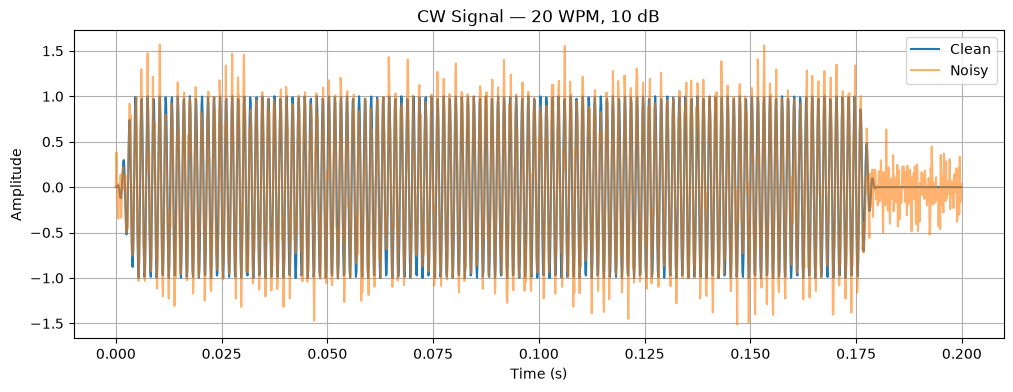

In [18]:
duration_to_plot = 0.20
num_samples = int(duration_to_plot * sample_rate)
t = np.arange(num_samples) / sample_rate

plt.figure(figsize=(12, 4))
plt.plot(t, clean_signal[:num_samples], label="Clean")
plt.plot(t, noisy_signal[:num_samples], label="Noisy", alpha=0.6)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title(f"CW Signal — {row['wpm']} WPM, " f"{row['snr_requested_db']} dB")
plt.legend()
plt.grid(True)
plt.show()

In [19]:
clean_windows, clean_pad, clean_length = (split_windows(clean_signal))
noisy_windows, noisy_pad, noisy_length = (split_windows(noisy_signal))
print("Clean windows:", clean_windows.shape)
print("Noisy windows:", noisy_windows.shape)
print("Clean padding:", clean_pad)
print("Noisy padding:", noisy_pad)

clean_merged = merge_windows(clean_windows, clean_length)
noisy_merged = merge_windows(noisy_windows, noisy_length)
clean_error = np.max(np.abs(clean_signal - clean_merged))
noisy_error = np.max(np.abs(noisy_signal - noisy_merged))
print(f"Clean windowing error = {clean_error:.6e}")
print(f"Noisy windowing error = {noisy_error:.6e}")

Clean windows: (377, 256)
Noisy windows: (377, 256)
Clean padding: 32
Noisy padding: 32
Clean windowing error = 0.000000e+00
Noisy windowing error = 0.000000e+00


## Check 1 noisy window 

In [20]:
energies = np.sum(clean_windows ** 2, axis=1)
signal_indices = np.where(energies > 1e-12)[0]
print(signal_indices[:20])

window_index = signal_indices[0]
window = clean_windows[window_index]
print("Window:", window_index)
print("Energy:", np.sum(window ** 2))

[ 0  1  2  3  4  5  7  8  9 11 12 13 14 15 16 18 19 20 26 27]
Window: 0
Energy: 116.02993831593962


## Check 1 noisy window for all transforms

In [21]:
retention = 0.10

TRANSFORMS = {
    "FFT":  (classical_fft,  classical_ifft,  True,  "classical"),
    "QFT":  (quantum_fft,    quantum_ifft,     True,  "quantum"),
    "DCT":  (classical_dct,  classical_idct,  False,  "classical"),
    "QDCT": (quantum_dct,    quantum_idct,    False,  "quantum"),
    "DST":  (classical_dst,  classical_idst,  False,  "classical"),
    "QDST": (quantum_dst,    quantum_idst,    False,  "quantum"),
    "DWT":  (classical_haar, classical_ihaar, False,  "classical"),
    "QDWT": (quantum_haar,   quantum_ihaar,   False,  "quantum"),
}

for name, (forward_fn, inverse_fn, is_fourier, implementation) in TRANSFORMS.items():
    result = compress_window(window, forward_fn, inverse_fn, retention, fourier=is_fourier,)
    metrics = waveform_metrics(window, result["reconstructed"])
    print(
        f"{name:5s} | "
        f"{implementation:9s} | "
        f"kept={result['num_kept']:3d} | "
        f"RMSE={metrics['rmse']:.6e} | "
        f"SNR={metrics['snr_db']:.2f} dB | "
        f"corr={metrics['correlation']:.6f} | "
        f"leak={result['forward_leakage']:.3e}"
    )

FFT   | classical | kept= 26 | RMSE=5.798569e-02 | SNR=21.30 dB | corr=0.996306 | leak=0.000e+00
QFT   | quantum   | kept= 26 | RMSE=5.798569e-02 | SNR=21.30 dB | corr=0.996306 | leak=0.000e+00
DCT   | classical | kept= 26 | RMSE=4.627148e-02 | SNR=23.26 dB | corr=0.997657 | leak=0.000e+00
QDCT  | quantum   | kept= 26 | RMSE=4.627148e-02 | SNR=23.26 dB | corr=0.997657 | leak=2.883e-13
DST   | classical | kept= 26 | RMSE=6.225701e-02 | SNR=20.68 dB | corr=0.995715 | leak=0.000e+00
QDST  | quantum   | kept= 26 | RMSE=6.225701e-02 | SNR=20.68 dB | corr=0.995715 | leak=2.920e-13
DWT   | classical | kept= 26 | RMSE=4.314783e-01 | SNR=3.86 dB | corr=0.767637 | leak=0.000e+00
QDWT  | quantum   | kept= 26 | RMSE=4.314783e-01 | SNR=3.86 dB | corr=0.767637 | leak=0.000e+00


## Test 1 CW recordings

In [22]:
dct_results = compress_recording(clean_signal, classical_dct, classical_idct, RETENTION_RATIOS)

for retention, result in dct_results.items():
    metrics = waveform_metrics(clean_signal, result["reconstructed"])
    print(f"{retention:5.0%} | kept={result['avg_kept']:6.1f} | RMSE={metrics['rmse']:.6e} | SNR={metrics['snr_db']:7.2f} dB | corr={metrics['correlation']:.6f}")

 100% | kept= 256.0 | RMSE=2.061922e-16 | SNR=    inf dB | corr=1.000000
  85% | kept= 218.0 | RMSE=3.389323e-04 | SNR=  63.26 dB | corr=1.000000
  75% | kept= 192.0 | RMSE=7.908804e-04 | SNR=  55.90 dB | corr=0.999999
  50% | kept= 128.0 | RMSE=3.257960e-03 | SNR=  43.60 dB | corr=0.999978
  45% | kept= 116.0 | RMSE=4.185182e-03 | SNR=  41.42 dB | corr=0.999964
  25% | kept=  64.0 | RMSE=1.603648e-02 | SNR=  29.76 dB | corr=0.999471
  10% | kept=  26.0 | RMSE=4.809286e-02 | SNR=  20.22 dB | corr=0.995231
   5% | kept=  13.0 | RMSE=7.422108e-02 | SNR=  16.45 dB | corr=0.988603
   2% | kept=   6.0 | RMSE=1.148498e-01 | SNR=  12.65 dB | corr=0.972489
   1% | kept=   3.0 | RMSE=1.703820e-01 | SNR=   9.23 dB | corr=0.938387


## Main Transforms

### Helper functions

In [23]:
CLASSICAL_TRANSFORMS = {name: config for name, config in TRANSFORMS.items() if config[3] == "classical"}
QUANTUM_TRANSFORMS = {name: config for name, config in TRANSFORMS.items() if config[3] == "quantum"}
def run_cw_experiment(clean_signal, noisy_signal, row, transforms=CLASSICAL_TRANSFORMS):
    rows, reconstructed_signals = [], {}

    for signal_type, signal in {"clean": clean_signal, "noisy": noisy_signal}.items():
        for name, (forward_fn, inverse_fn, fourier, implementation) in transforms.items():
            print(f"msg={row['message_id']} wpm={row['wpm']} snr={row['snr_requested_db']} | {signal_type} | {name}")
            results = compress_recording(signal, forward_fn, inverse_fn, RETENTION_RATIOS, fourier)

            for retention, result in results.items():
                input_m = waveform_metrics(signal, result["reconstructed"])
                clean_m = waveform_metrics(clean_signal, result["reconstructed"])

                rows.append({
                    "message_id": row["message_id"], "wpm": row["wpm"], "snr_requested_db": row["snr_requested_db"],
                    "signal_type": signal_type, "transform": name, "implementation": implementation,
                    "retention_requested": retention, "retention_actual": result["actual_retention"],
                    "avg_kept": result["avg_kept"], "rmse": input_m["rmse"], "snr_db": input_m["snr_db"],
                    "correlation": input_m["correlation"], "rmse_vs_clean": clean_m["rmse"],
                    "snr_vs_clean_db": clean_m["snr_db"], "corr_vs_clean": clean_m["correlation"],
                })

                reconstructed_signals[(signal_type, name, retention)] = result["reconstructed"]

    return pd.DataFrame(rows), reconstructed_signals

## Sanity checks

In [24]:
def validate_quantum_recording(signal, name, forward_fn, inverse_fn, fourier=False):
    windows, _, _ = split_windows(signal)
    for wi, window in enumerate(windows):
        try:
            coeffs, _, _ = unpack_transform_result(forward_fn(window))
            for retention in RETENTION_RATIOS:
                compressed, _ = prune_coeffs(coeffs, retention, fourier)
                inverse_fn(compressed)
            print(f"{name} [{wi + 1}/{len(windows)}] OK")
        except Exception as e:
            print(f"\n{name} FAILED window={wi} retention={retention:.2%} | {type(e).__name__}: {e}")
            raise

In [ ]:
validate_quantum_recording(clean_signal, "QFT", quantum_fft, quantum_ifft, True)
validate_quantum_recording(clean_signal, "QDCT", quantum_dct, quantum_idct)
validate_quantum_recording(clean_signal, "QDST", quantum_dst, quantum_idst)
validate_quantum_recording(clean_signal, "QDWT", quantum_haar, quantum_ihaar)

QFT [1/377] OK
QFT [2/377] OK
QFT [3/377] OK
QFT [4/377] OK
QFT [5/377] OK
QFT [6/377] OK
QFT [7/377] OK
QFT [8/377] OK
QFT [9/377] OK
QFT [10/377] OK
QFT [11/377] OK
QFT [12/377] OK
QFT [13/377] OK
QFT [14/377] OK
QFT [15/377] OK
QFT [16/377] OK
QFT [17/377] OK
QFT [18/377] OK
QFT [19/377] OK
QFT [20/377] OK
QFT [21/377] OK
QFT [22/377] OK
QFT [23/377] OK
QFT [24/377] OK
QFT [25/377] OK
QFT [26/377] OK
QFT [27/377] OK
QFT [28/377] OK
QFT [29/377] OK
QFT [30/377] OK
QFT [31/377] OK
QFT [32/377] OK
QFT [33/377] OK
QFT [34/377] OK
QFT [35/377] OK
QFT [36/377] OK
QFT [37/377] OK
QFT [38/377] OK
QFT [39/377] OK
QFT [40/377] OK
QFT [41/377] OK
QFT [42/377] OK
QFT [43/377] OK
QFT [44/377] OK
QFT [45/377] OK
QFT [46/377] OK
QFT [47/377] OK
QFT [48/377] OK
QFT [49/377] OK
QFT [50/377] OK
QFT [51/377] OK
QFT [52/377] OK
QFT [53/377] OK
QFT [54/377] OK
QFT [55/377] OK
QFT [56/377] OK
QFT [57/377] OK
QFT [58/377] OK
QFT [59/377] OK
QFT [60/377] OK
QFT [61/377] OK
QFT [62/377] OK
QFT [63/377] OK
Q

### Dataset Sweep

In [ ]:
all_results = []
all_reconstructed = {}
clean_done = set()

CLASSICAL_TRANSFORMS = {name: config for name, config in TRANSFORMS.items() if config[3] == "classical"}
QUANTUM_TRANSFORMS = {name: config for name, config in TRANSFORMS.items() if config[3] == "quantum"}

for i, row in metadata.iterrows():
    sample = load_cw_sample(row)
    clean_id = (row["message_id"], row["wpm"])
    result_df, reconstructed_signals = run_cw_experiment(sample["clean"], sample["noisy"], row, transforms=TRANSFORMS)

    include_clean = clean_id not in clean_done
    if include_clean:
        clean_done.add(clean_id)
    else:
        result_df = result_df[result_df["signal_type"] != "clean"]

    all_results.append(result_df)
    for (signal_type, transform, retention), waveform in reconstructed_signals.items():
        if signal_type == "clean" and not include_clean: continue

        if signal_type == "clean":
            key = f"msg{int(row['message_id']):03d}_wpm{int(row['wpm']):02d}_clean_{transform}_r{int(round(retention * 100)):03d}"
        else:
            key = f"msg{int(row['message_id']):03d}_wpm{int(row['wpm']):02d}_snr{int(row['snr_requested_db']):+d}_{transform}_r{int(round(retention * 100)):03d}"

        all_reconstructed[key] = waveform

    print(f"[{i + 1}/{len(metadata)}] complete")

full_results = pd.concat(all_results, ignore_index=True)
full_results["retention_pct"] = full_results["retention_requested"] * 100
full_results.to_csv("cw_compression_full_results.csv", index=False)
np.savez_compressed("cw_reconstructed_signals.npz", **all_reconstructed)

In [ ]:
full_results.pivot_table(index=["signal_type", "retention_requested"], columns="transform", values="rmse_vs_input")

In [ ]:
full_results[full_results["signal_type"] == "noisy"].pivot(index="retention_requested", columns="transform", values="snr_vs_clean_db")

## Plots

In [ ]:
full_results["retention_pct"] = full_results["retention_requested"] * 100
full_results = full_results.replace([np.inf, -np.inf], np.nan)

sns.set_theme(style="whitegrid", context="paper")

In [ ]:
family_map = {"FFT":"Fourier", "QFT":"Fourier", "DCT":"Cosine", "QDCT":"Cosine", "DST":"Sine", "QDST":"Sine", "DWT":"Haar", "QDWT":"Haar"}
full_results["family"] = full_results["transform"].map(family_map)

### RSME vs Retentions

In [ ]:
g = sns.relplot(data=full_results, x="retention_pct", y="rmse_vs_input", hue="transform", col="signal_type", kind="line", marker="o", height=4.5, aspect=1.25)
g.set_axis_labels("Retained coefficients (%)", "RMSE")
g.set_titles("{col_name} CW")
for ax in g.axes.flat: ax.invert_xaxis()
plt.show()

### Reconstruction SNR

In [ ]:
g = sns.relplot(data=full_results, x="retention_pct", y="snr_vs_input_db", hue="transform", col="signal_type", kind="line", marker="o", height=4.5, aspect=1.25)
g.set_axis_labels("Retained coefficients (%)", "Reconstruction SNR (dB)")
g.set_titles("{col_name} CW")
for ax in g.axes.flat: ax.invert_xaxis()
plt.show()

#### Reconstruction SNR vs Clean references

In [ ]:
noisy_df = full_results[full_results["signal_type"] == "noisy"]

plt.figure(figsize=(10, 6))
sns.lineplot(data=noisy_df, x="retention_pct", y="snr_vs_clean_db", hue="transform", marker="o")
plt.xlabel("Retained coefficients (%)")
plt.ylabel("SNR vs clean CW (dB)")
plt.title("Noisy CW Reconstruction Quality vs Clean Reference")
plt.gca().invert_xaxis()
plt.tight_layout()
plt.show()

### Correlation vs Retention

In [ ]:
g = sns.relplot(data=full_results, x="retention_pct", y="corr_vs_input", hue="transform", col="signal_type", kind="line", marker="o", height=4.5, aspect=1.25)
g.set_axis_labels("Retained coefficients (%)", "Correlation")
g.set_titles("{col_name} CW")
for ax in g.axes.flat:
    ax.invert_xaxis()
    ax.set_ylim(0, 1.01)
plt.show()

### Classical vs Quantum Counterparts

In [ ]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=full_results[full_results["signal_type"] == "clean"], x="retention_pct", y="rmse_vs_input", hue="family", style="implementation", markers=True)
plt.xlabel("Retained coefficients (%)")
plt.ylabel("RMSE")
plt.title("Classical vs Quantum Transform Compression — Clean CW")
plt.gca().invert_xaxis()
plt.tight_layout()
plt.show()

### Noisy classical vs quantum

In [ ]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=noisy_df, x="retention_pct", y="rmse_vs_clean", hue="family", style="implementation", markers=True)
plt.xlabel("Retained coefficients (%)")
plt.ylabel("RMSE vs clean CW")
plt.title("Classical vs Quantum Compression of Noisy CW")
plt.gca().invert_xaxis()
plt.tight_layout()
plt.show()

### WPM vs Retention vs Transform

In [ ]:
clean = full_results[full_results["signal_type"] == "clean"]
g = sns.relplot(data=clean, x="retention_pct", y="rmse_vs_clean", hue="transform", col="wpm", col_wrap=3, kind="line", marker="o", estimator="mean", errorbar="sd", height=3.8, aspect=1.15)
g.set_axis_labels("Retained coefficients (%)", "RMSE")
g.set_titles("{col_name} WPM")
for ax in g.axes.flat: ax.invert_xaxis()
plt.show()

#### Noisy WPM vs retention vs transform at one SNR

In [ ]:
noisy10 = full_results[(full_results["signal_type"] == "noisy") & (full_results["snr_requested_db"] == 10)]

g = sns.relplot(data=noisy10, x="retention_pct", y="snr_vs_clean_db", hue="transform", col="wpm", col_wrap=3, kind="line", marker="o", estimator="mean", errorbar="sd", height=3.8, aspect=1.15)
g.set_axis_labels("Retained coefficients (%)", "SNR vs clean CW (dB)")
g.set_titles("{col_name} WPM — 10 dB input")
for ax in g.axes.flat: ax.invert_xaxis()
plt.show()

#### WPM vs SNR vs transform

In [ ]:
five = full_results[(full_results["signal_type"] == "noisy") & np.isclose(full_results["retention_requested"], 0.05)]

g = sns.relplot(data=five, x="wpm", y="snr_vs_clean_db", hue="transform", col="snr_requested_db", col_wrap=4, kind="line", marker="o", estimator="mean", errorbar="sd", height=3.4, aspect=1.05)
g.set_axis_labels("WPM", "Reconstructed SNR vs clean (dB)")
g.set_titles("Input SNR = {col_name} dB")
plt.show()

### Heatmap

#### Clean RMSE

In [ ]:
heat = full_results[full_results["signal_type"] == "clean"].pivot(index="transform", columns="retention_pct", values="rmse_vs_input")

plt.figure(figsize=(11, 5))
sns.heatmap(heat, annot=True, fmt=".3f", cmap="viridis_r")
plt.xlabel("Retained coefficients (%)")
plt.ylabel("Transform")
plt.title("CW Reconstruction RMSE")
plt.tight_layout()
plt.show()

#### Noisy-to-clean SNR

In [ ]:
heat = noisy_df.pivot(index="transform", columns="retention_pct", values="snr_vs_clean_db")

plt.figure(figsize=(11, 5))
sns.heatmap(heat, annot=True, fmt=".1f", cmap="viridis")
plt.xlabel("Retained coefficients (%)")
plt.ylabel("Transform")
plt.title("Noisy CW Reconstruction SNR vs Clean Reference (dB)")
plt.tight_layout()
plt.show()

#### WPM vs retention heatmaps per transform

In [ ]:
for transform in ["FFT", "DCT", "DST", "DWT"]:
    subset = clean[clean["transform"] == transform]
    heat = subset.pivot_table(index="wpm", columns="retention_pct", values="rmse_vs_clean", aggfunc="mean")
    plt.figure(figsize=(10, 4))
    sns.heatmap(heat, annot=True, fmt=".3f", cmap="viridis_r")
    plt.title(f"{transform} — RMSE by WPM and Retention")
    plt.xlabel("Retained coefficients (%)")
    plt.ylabel("WPM")
    plt.tight_layout()
    plt.show()

### 10% coefficient retention

In [ ]:
ten = full_results[(full_results["signal_type"] == "clean") & np.isclose(full_results["retention_requested"], 0.10)]

plt.figure(figsize=(9, 5))
sns.barplot(data=ten, x="transform", y="rmse_vs_input")
plt.xlabel("Transform")
plt.ylabel("RMSE")
plt.title("CW Reconstruction at 10% Coefficient Retention")
plt.tight_layout()
plt.show()

## Qubit Aer Noise injection

### Helper functions 

In [ ]:
def run_noisy_transform(x, transform, simulator):
    qc, norm, n = build_transform_pipeline(x, transform)
    if qc is None: return {"fidelity": 1.0, "leakage": 0.0, "depth": 0, "size": 0, "ops": {}}
    ideal = Statevector.from_instruction(qc)
    noisy_qc = qc.copy()
    noisy_qc.save_density_matrix()
    tqc = transpile(noisy_qc, simulator, optimization_level=1)
    result = simulator.run(tqc).result()
    rho = DensityMatrix(result.data(0)["density_matrix"])
    fidelity = float(state_fidelity(ideal, rho))
    leakage = 0.0
    if transform.num_qubits == n + 1:
        N = 2 ** n
        diagonal = np.real(np.diag(rho.data))
        leakage = max(0.0, 1.0 - float(np.sum(diagonal[:N])))

    return {"fidelity": fidelity, "leakage": leakage, "depth": tqc.depth(), "size": tqc.size(), "ops": dict(tqc.count_ops())}

def noise_analyze_recording(signal, simulator):
    windows, _, _ = split_windows(signal)
    rows = []

    for name, builder in NOISY_TRANSFORMS.items():
        fidelities, leakages = [], []

        for window in windows:
            if np.linalg.norm(window) <= 1e-15: continue
            n = int(np.log2(len(window)))
            m = run_noisy_transform(window, builder(n), simulator)
            fidelities.append(m["fidelity"])
            leakages.append(m["leakage"])

        rows.append({
            "transform": name,
            "fidelity_mean": np.mean(fidelities),
            "fidelity_std": np.std(fidelities),
            "fidelity_min": np.min(fidelities),
            "leakage_mean": np.mean(leakages),
            "leakage_max": np.max(leakages),
        })

    return pd.DataFrame(rows)

In [ ]:
NOISY_TRANSFORMS = {
    "QFT": lambda n: build_iqft(n),
    "QDCT": build_qdct,
    "QDST": build_qdst,
    "QDWT": build_qhaar,
}

### 1 clean CW window test

In [ ]:
window = clean_windows[signal_indices[0]]
n = int(np.log2(len(window)))
noise_results = []

for noise_name, (p1, p2) in NOISE_LEVELS.items():
    simulator = AerSimulator(method="density_matrix", noise_model=build_noise_model(p1, p2))
    for transform_name, builder in NOISY_TRANSFORMS.items():
        transform = builder(n)
        m = run_noisy_transform(window, transform, simulator)
        noise_results.append({"noise": noise_name, "p1": p1, "p2": p2, "transform": transform_name, **m})

noise_results = pd.DataFrame(noise_results)
noise_results

## Quantum noise simulators

In [ ]:
all_noise_results = []

for device_name, simulator in NOISE_SIMULATORS.items():
    print(f"Device: {device_name}")

    for signal_type, signal in {"clean": clean_signal, "noisy": noisy_signal}.items():
        df = noise_analyze_recording(signal, simulator)
        df["signal_type"] = signal_type
        df["device"] = device_name
        all_noise_results.append(df)

noise_results = pd.concat(all_noise_results, ignore_index=True)
noise_results.to_csv("cw_quantum_noise_results.csv", index=False)